In [45]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Load the dataset
# Ensure the .dta file is in your working directory
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta").dropna()

# 2. Data Preparation
# Create a datetime column for easier filtering (assuming year, month, day, hour exist)
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Define the "Post" dummy: 1 if date is after Jan 1, 2005 (Start of ETS)
df['Post'] = (df['year'] >= 2005).astype(int)

# Define the "Treated" dummy: Peak hours (usually defined as 8am to 8pm)
# The dataset variable 'peak' likely already captures this (1=Peak, 0=Off-Peak)
df['Treated'] = df['peak']

# Create the Interaction Term (The DiD Estimator)
df['Treated_Post'] = df['Treated'] * df['Post']

df


,year,month,day,hour,mg_price,eprice,coal,gas,brent,totalcost,...,ltotalcost2_peak,ltotalcost2_off,ecost2_peak,ecost2_off,lecost2_peak,lecost2_off,date,Post,Treated,Treated_Post
4,2004.0,1.0,1.0,5,16.54,0.00,0.6668,1.3055,1.7566,20.158566,...,0.000000,3.052045,0.000000,0.000000,0.000000,0.000000,2004-01-01 05:00:00,0,0.0,0.0
6,2004.0,1.0,1.0,7,14.54,0.00,0.6668,1.3055,1.7566,21.075415,...,0.000000,3.094465,0.000000,0.000000,0.000000,0.000000,2004-01-01 07:00:00,0,0.0,0.0
10,2004.0,1.0,1.0,11,10.01,0.00,0.6668,1.3055,1.7566,20.546642,...,3.070220,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 11:00:00,0,1.0,0.0
15,2004.0,1.0,1.0,16,10.12,0.00,0.6668,1.3055,1.7566,20.159899,...,3.052108,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 16:00:00,0,1.0,0.0
17,2004.0,1.0,1.0,18,10.22,0.00,0.6668,1.3055,1.7566,19.818497,...,3.035842,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 18:00:00,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,2007.0,6.0,30.0,20,31.60,0.14,0.7288,1.4082,4.0270,27.316673,...,3.343451,0.000000,0.051533,0.000000,0.050249,0.000000,2007-06-30 20:00:00,1,1.0,1.0
30644,2007.0,6.0,30.0,21,31.62,0.14,0.7288,1.4082,4.0270,24.073147,...,0.000000,3.221797,0.000000,0.144442,0.000000,0.134917,2007-06-30 21:00:00,1,0.0,0.0
30645,2007.0,6.0,30.0,22,35.00,0.14,0.7288,1.4082,4.0270,26.988102,...,0.000000,3.331779,0.000000,0.049664,0.000000,0.048470,2007-06-30 22:00:00,1,0.0,0.0
30646,2007.0,6.0,30.0,23,40.07,0.14,0.7288,1.4082,4.0270,27.313765,...,0.000000,3.343348,0.000000,0.048624,0.000000,0.047479,2007-06-30 23:00:00,1,0.0,0.0


In [39]:
# 3. Define the Regression Equation
# We control for supply costs (coal, gas, oil), weather (wind, temp), 
# and use Fixed Effects (C(var)) for seasonality.
regression_formula = r"""mg_price ~ Treated_Post + Treated + Post + coal + gas + brent + windx + temp + humid + C(month) + C(day) + C(hour)"""

# 4. Run the Regression
# We use Newey-West standard errors (cov_type='HAC') to account for 
# the high-frequency serial correlation/volatility in electricity prices.
model = smf.ols(regression_formula, data=df)
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 5. Output results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:                mg_price   R-squared:                       0.522
Model:                             OLS   Adj. R-squared:                  0.520
Method:                  Least Squares   F-statistic:                     51.52
Date:              ven., 02 janv. 2026   Prob (F-statistic):               0.00
Time:                         17:51:20   Log-Likelihood:                -65683.
No. Observations:                17309   AIC:                         1.315e+05
Df Residuals:                    17236   BIC:                         1.321e+05
Df Model:                           72                                         
Covariance Type:                   HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           40.6502   

e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 73, but rank is 72
  warnings.warn('covariance of constraints does not have full '


In [46]:
regression_formula = r"""mg_price ~ Treated_Post + Treated + Post + coal + gas + brent + windx + temp + humid"""

# 4. Run the Regression
# We use Newey-West standard errors (cov_type='HAC') to account for 
# the high-frequency serial correlation/volatility in electricity prices.
model = smf.ols(regression_formula, data=df)
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 5. Output results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:                mg_price   R-squared:                       0.382
Model:                             OLS   Adj. R-squared:                  0.381
Method:                  Least Squares   F-statistic:                     225.7
Date:              ven., 02 janv. 2026   Prob (F-statistic):               0.00
Time:                         18:17:28   Log-Likelihood:                -67907.
No. Observations:                17309   AIC:                         1.358e+05
Df Residuals:                    17299   BIC:                         1.359e+05
Df Model:                            9                                         
Covariance Type:                   HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       26.9919      6.109    

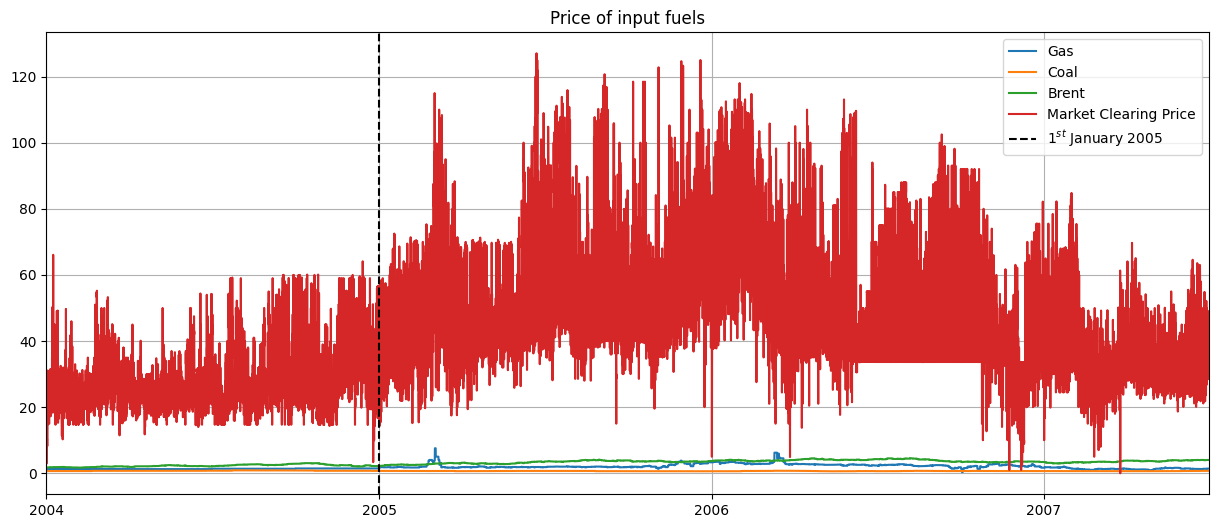

In [43]:
import matplotlib.pyplot as plt
df2 = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
x = np.linspace(0, df2.shape[0]-1, df2.shape[0])
fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(x, df["gas"], label="Gas")
plt.plot(x, df["coal"], label="Coal")
plt.plot(x, df["brent"], label="Brent")
plt.plot(x, df2["mg_price"], label="Market Clearing Price")
plt.axvline(8784, 0, 8, color="k", ls="--", label="1$^{st}$ January 2005")
# plt.ylim(0, 8)
plt.xlim(0, df.shape[0])
plt.xticks([0, 8784, 8784+8760, 8784+8760+8760], ["2004", "2005", "2006", "2007"])
plt.grid()
plt.legend()
plt.title("Price of input fuels")
plt.show()